In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from factor_analyzer import FactorAnalyzer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
# =========================
# 1. 读取数据
# =========================

file_path = "clean.xlsx"
df = pd.read_excel(file_path)

In [3]:
# =========================
# 2. 机制变量题项
# =========================

system_items_clean = [
    "Q10","Q11","Q12","Q13","Q14",
    "Q15","Q16","Q17","Q18",
    "Q31","Q32","Q35"
]

pressure_items = [
    "Q19","Q20","Q21","Q22",
    "Q23","Q24","Q25","Q36"
]

In [4]:
# =========================
# 3. 单因子分析构建 F1_clean
#    （不旋转，更符合单因子情形）
# =========================

X_system = df[system_items_clean].dropna()

fa_system = FactorAnalyzer(
    n_factors=1,
    rotation=None,
    method="principal"
)

fa_system.fit(X_system)

df.loc[X_system.index, "F1_clean"] = fa_system.transform(X_system)[:, 0]


C:\Users\13273\AppData\Roaming\Python\Python39\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\13273\AppData\Roaming\Python\Python39\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [5]:
# =========================
# 4. 单因子分析构建 F2_clean
# =========================

X_pressure = df[pressure_items].dropna()

fa_pressure = FactorAnalyzer(
    n_factors=1,
    rotation=None,
    method="principal"
)

fa_pressure.fit(X_pressure)

df.loc[X_pressure.index, "F2_clean"] = fa_pressure.transform(X_pressure)[:, 0]


C:\Users\13273\AppData\Roaming\Python\Python39\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\13273\AppData\Roaming\Python\Python39\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [6]:
# =========================
# 5. 仅保留用于聚类的机制因子
# =========================

X = df[["F1_clean", "F2_clean"]].dropna().copy()


In [7]:
# =========================
# 6. 聚类前标准化
# =========================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

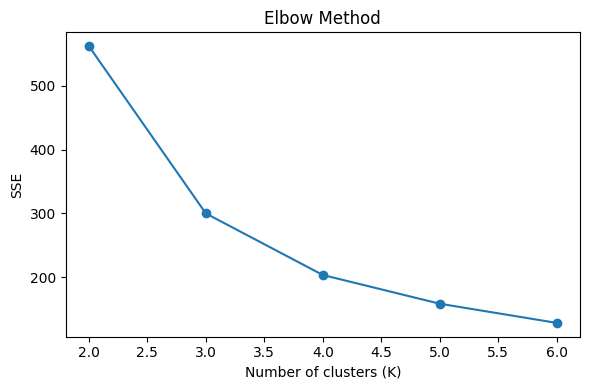

In [8]:
# =========================
# 7. 肘部法则（选择K）
# =========================

sse = []
K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=123, n_init=20)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K_range, sse, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("SSE")
plt.title("Elbow Method")
plt.tight_layout()
plt.show()

In [9]:
# =========================
# 8. 轮廓系数
# =========================

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=123, n_init=20)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K = {k}, silhouette = {score:.3f}")

K = 2, silhouette = 0.470
K = 3, silhouette = 0.518
K = 4, silhouette = 0.500
K = 5, silhouette = 0.471
K = 6, silhouette = 0.412


In [10]:
# =========================
# 9. 设定最终聚类数
# =========================

k_final = 3

kmeans = KMeans(
    n_clusters=k_final,
    random_state=123,
    n_init=20
)

labels = kmeans.fit_predict(X_scaled)

X["cluster"] = labels


# 同步回原始数据表
df.loc[X.index, "cluster"] = labels

In [11]:
# =========================
# 10. 各类样本数量
# =========================

print("\n各类样本数量：")
print(X["cluster"].value_counts().sort_index())


各类样本数量：
cluster
0    110
1    211
2    221
Name: count, dtype: int64


In [12]:
# =========================
# 11. 聚类中心（标准化空间）
# =========================

centers_scaled = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=["F1_clean", "F2_clean"]
)

print("\n聚类中心（标准化空间）：")
print(centers_scaled)


聚类中心（标准化空间）：
   F1_clean  F2_clean
0  1.600827  0.480617
1 -0.550456 -1.094809
2 -0.271243  0.806049


In [13]:
# =========================
# 12. 聚类中心（还原到原始因子空间，便于论文解释）
# =========================

centers_original = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=["F1_clean", "F2_clean"]
)

print("\n聚类中心（原始因子空间）：")
print(centers_original)


聚类中心（原始因子空间）：
   F1_clean  F2_clean
0  1.600827  0.480617
1 -0.550456 -1.094809
2 -0.271243  0.806049


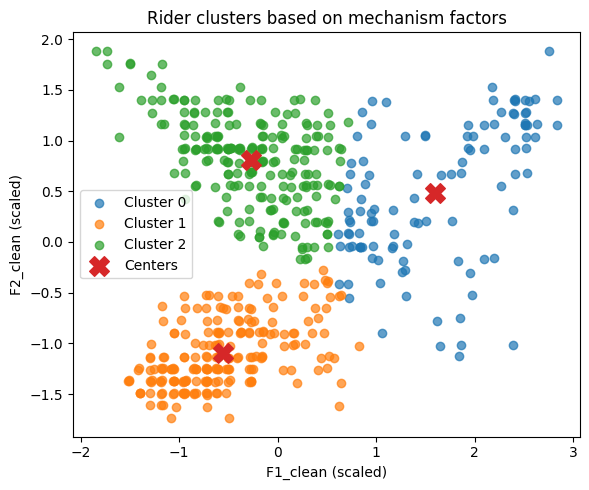

In [14]:
# =========================
# 13. 二维可视化
# =========================

plt.figure(figsize=(6, 5))

for c in range(k_final):
    plt.scatter(
        X_scaled[X["cluster"] == c, 0],
        X_scaled[X["cluster"] == c, 1],
        label=f"Cluster {c}",
        alpha=0.7
    )

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    marker="X",
    label="Centers"
)

plt.xlabel("F1_clean (scaled)")
plt.ylabel("F2_clean (scaled)")
plt.title("Rider clusters based on mechanism factors")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# =========================
# 14. 各类画像均值（原始因子得分）
# =========================

profile = X.groupby("cluster")[["F1_clean", "F2_clean"]].mean()

print("\n各类画像均值（原始因子得分）：")
print(profile)


各类画像均值（原始因子得分）：
         F1_clean  F2_clean
cluster                    
0        1.600827  0.480617
1       -0.550456 -1.094809
2       -0.271243  0.806049


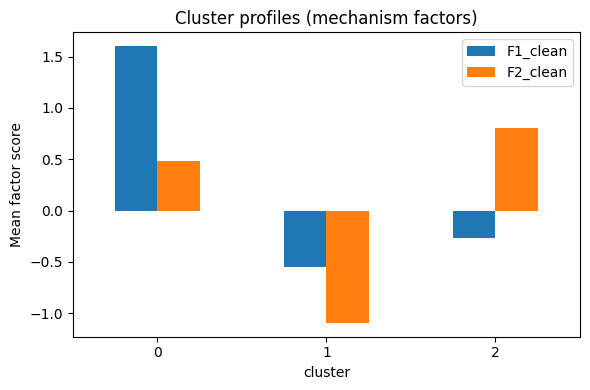

In [16]:
# =========================
# 15. 画像柱状图
# =========================

profile.plot(kind="bar", figsize=(6, 4))
plt.ylabel("Mean factor score")
plt.title("Cluster profiles (mechanism factors)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
df.groupby("cluster")[["Q37","Q38","Q39"]].mean()

,Q37,Q38,Q39
cluster,,,
0.0,3.381818,3.500000,3.481818
1.0,2.061611,1.914692,2.080569
2.0,2.140271,2.199095,2.199095


In [18]:
df.groupby("cluster")[["F1_clean","F2_clean"]].mean()

,F1_clean,F2_clean
cluster,,
0.0,1.600827,0.480617
1.0,-0.550456,-1.094809
2.0,-0.271243,0.806049


In [19]:
df["cluster"] = pd.NA
df.loc[X.index, "cluster"] = labels
df["cluster"] = df["cluster"].astype("Int64")
df["cluster"]

0      2
1      0
2      2
3      0
4      0
      ..
537    1
538    1
539    1
540    1
541    1
Name: cluster, Length: 542, dtype: Int64

In [21]:
# =========================
# 16. 画像对比分析
# =========================

#  "性别","年龄","从业年限","每日工作时长","收入"
df.groupby("cluster")[[
    "Q4","Q5","Q7","Q9","Q30"
]].mean()



,Q4,Q5,Q7,Q9,Q30
cluster,,,,,
0,1.427273,2.318182,2.727273,2.263636,2.190909
1,1.436019,3.914692,4.284360,2.426540,2.876777
2,1.416290,2.610860,2.619910,2.276018,2.601810


In [22]:
df.groupby("cluster")[["F1_clean","F2_clean"]].mean()


,F1_clean,F2_clean
cluster,,
0,1.600827,0.480617
1,-0.550456,-1.094809
2,-0.271243,0.806049


In [23]:
vars_cate = {
    "性别(Q4)": "Q4",
    "年龄(Q5)": "Q5",
    "用工类型(Q6)": "Q6",
    "从业年限(Q7)": "Q7",
    "日配送时长(Q9)": "Q9",
    "月均收入(Q30)": "Q30",
}

def crosstab_n_pct(df, row="cluster", col="Q4"):
    ct_n = pd.crosstab(df[row], df[col], dropna=False)
    ct_pct = ct_n.div(ct_n.sum(axis=1), axis=0) * 100
    # 拼成 “n(%)”
    out = ct_n.astype(int).astype(str) + " (" + ct_pct.round(1).astype(str) + "%)"
    return out

for title, col in vars_cate.items():
    tab = crosstab_n_pct(df, row="cluster", col=col)
    print("\n====", title, "====")
    print(tab)


==== 性别(Q4) ====
Q4                 1           2
cluster                         
0         63 (57.3%)  47 (42.7%)
1        119 (56.4%)  92 (43.6%)
2        129 (58.4%)  92 (41.6%)

==== 年龄(Q5) ====
Q5                1           2           3            4           5
cluster                                                             
0        30 (27.3%)  38 (34.5%)  27 (24.5%)     7 (6.4%)    8 (7.3%)
1          2 (0.9%)    4 (1.9%)  45 (21.3%)  119 (56.4%)  41 (19.4%)
2        28 (12.7%)  86 (38.9%)  67 (30.3%)   24 (10.9%)   16 (7.2%)

==== 用工类型(Q6) ====
Q6                 1            2
cluster                          
0         68 (61.8%)   42 (38.2%)
1        170 (80.6%)   41 (19.4%)
2        114 (51.6%)  107 (48.4%)

==== 从业年限(Q7) ====
Q7                1           2           3            4           5
cluster                                                             
0        17 (15.5%)  39 (35.5%)  21 (19.1%)   23 (20.9%)   10 (9.1%)
1          3 (1.4%)    2 (0.9%)    4 